<a href="https://colab.research.google.com/github/ananaysaharan/DL_Basics/blob/main/training_basicNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Define XOR inputs
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Define XOR outputs
y = np.array([0, 1, 1, 0])

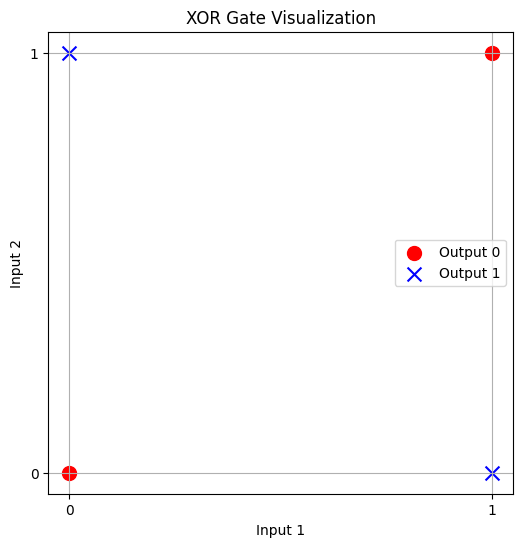

In [ ]:
# Plot the XOR data points
plt.figure(figsize=(6, 6))

# Class 0 points (output = 0)
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', marker='o', s=100, label='Output 0')

# Class 1 points (output = 1)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='x', s=100, label='Output 1')

plt.title('XOR Gate Visualization')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.grid(True)
plt.legend()
plt.show()

As you can see from the plot, there's no
single straight line (hyperplane in higher dimensions) that can perfectly separate the red circles (output 0) from the blue crosses (output 1). This demonstrates that the XOR function is not linearly separable, which is a fundamental concept in the study of neural networks and machine learning, particularly regarding the limitations of single-layer perceptrons.

### Part 2: Building a Neural Network for XOR

Now, let's try to solve the XOR problem using a simple feedforward neural network. We'll use the following architecture:

*   **Input Layer:** 2 neurons (for the two XOR inputs)
*   **Hidden Layer:** 4 neurons
*   **Output Layer:** 1 neuron (for the XOR output)

We will use the sigmoid activation function for both the hidden and output layers.

### Mathematical Formulas for the Neural Network

Let's break down the forward propagation, loss calculation, and backpropagation steps with their mathematical formulas.

#### 1. Forward Propagation

Forward propagation involves calculating the output of the network given the inputs, weights, and biases.

##### Input to Hidden Layer

For each input sample $x$ (a row from `X`):

$$ \text{hidden\_layer\_input} = x \cdot W_h + b_h $$

$$ \text{hidden\_layer\_activation} = \sigma(\text{hidden\_layer\_input}) $$

Where:
*   $x$ is the input vector (1x2)
*   $W_h$ (`wh`) is the weight matrix from the input to the hidden layer (2x4)
*   $b_h$ (`bh`) is the bias vector for the hidden layer (1x4)
*   $\sigma$ is the sigmoid activation function: $\sigma(z) = \frac{1}{1 + e^{-z}}$

##### Hidden to Output Layer

$$ \text{output\_layer\_input} = \text{hidden\_layer\_activation} \cdot W_{out} + b_{out} $$

$$ \text{predicted\_output} = \sigma(\text{output\_layer\_input}) $$

Where:
*   $\text{hidden\_layer\_activation}$ is the output from the hidden layer (1x4)
*   $W_{out}$ (`wout`) is the weight matrix from the hidden to the output layer (4x1)
*   $b_{out}$ (`bout`) is the bias vector for the output layer (1x1)

In [ ]:
# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [ ]:
# Neural network architecture parameters
input_neurons = 2
hidden_neurons = 4
output_neurons = 1

# Learning rate
learning_rate = 0.1

# Number of training epochs
epochs = 10000

# Initialize weights and biases randomly
# Weights from input to hidden layer
wh = np.random.uniform(size=(input_neurons, hidden_neurons))

# Bias for hidden layer
bh = np.random.uniform(size=(1, hidden_neurons))

# Weights from hidden to output layer
wout = np.random.uniform(size=(hidden_neurons, output_neurons))

# Bias for output layer
bout = np.random.uniform(size=(1, output_neurons))

print("Initial Weights (Input to Hidden):")
print(wh)
print("Initial Biases (Hidden):")
print(bh)
print("Initial Weights (Hidden to Output):")
print(wout)
print("Initial Biases (Output):")
print(bout)

Initial Weights (Input to Hidden):
[[0.45283322 0.81385421 0.66285242 0.80849631]
 [0.40468805 0.62017985 0.62746505 0.21429509]]
Initial Biases (Hidden):
[[0.08815976 0.24349074 0.96702419 0.0284625 ]]
Initial Weights (Hidden to Output):
[[0.90479316]
 [0.49562857]
 [0.92124401]
 [0.89651977]]
Initial Biases (Output):
[[0.84052583]]


#### 2. Loss Calculation

The loss function quantifies how far the network's predictions are from the actual values. We will now use Mean Squared Error (MSE).

We calculate the error in the output layer as:

$$ \text{error\_output\_layer} = \text{predicted\_output} - y $$

Where:
*   $y$ is the actual target output (1x1)
*   $\text{predicted\_output}$ is the output generated by the network.

Then, the Mean Squared Error (MSE) is calculated as:

$$ \text{Loss (MSE)} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \text{predicted\_output}_i)^2 $$

#### 3. Backpropagation and Weight Updates

Backpropagation is used to adjust the network's weights and biases to minimize the loss. It involves calculating the gradient of the loss function with respect to each weight and bias.

##### Output Layer Weight and Bias Update

First, calculate the derivative of the loss with respect to the output layer's input (this incorporates the sigmoid derivative):

$$ \text{d\_predicted\_output} = \text{error\_output\_layer} \times \sigma'(\text{predicted\_output}) $$

Where $\sigma'(z) = z(1-z)$ for the sigmoid derivative.

Then, update the output layer's weights and biases:

$$ W_{out} = W_{out} + \text{hidden\_layer\_activation}^T \cdot \text{d\_predicted\_output} \times \text{learning\_rate} $$

$$ b_{out} = b_{out} + \text{sum}(\text{d\_predicted\_output}) \times \text{learning\_rate} $$

##### Hidden Layer Weight and Bias Update

Calculate the error contribution of the hidden layer:

$$ \text{error\_hidden\_layer} = \text{d\_predicted\_output} \cdot W_{out}^T $$

Then, calculate the derivative of the loss with respect to the hidden layer's input:

$$ \text{d\_hidden\_layer} = \text{error\_hidden\_layer} \times \sigma'(\text{hidden\_layer\_activation}) $$

Finally, update the hidden layer's weights and biases:

$$ W_h = W_h + X^T \cdot \text{d\_hidden\_layer} \times \text{learning\_rate} $$

$$ b_h = b_h + \text{sum}(\text{d\_hidden\_layer}) \times \text{learning\_rate} $$

Where $\text{learning\_rate}$ is a hyperparameter that controls the step size during optimization.

In [ ]:
# Training the Neural Network

losses = []

for i in range(epochs):
    # Forward Propagation
    # Input to Hidden Layer
    hidden_layer_input = np.dot(X, wh) + bh
    hidden_layer_activation = sigmoid(hidden_layer_input)

    # Hidden to Output Layer
    output_layer_input = np.dot(hidden_layer_activation, wout) + bout
    predicted_output = sigmoid(output_layer_input)

    # Backpropagation
    # Calculate error in output layer (for MSE derivative)
    error_output_layer = predicted_output - y.reshape(-1, 1) # Changed for MSE derivative
    d_predicted_output = error_output_layer * sigmoid_derivative(predicted_output)

    # Calculate error in hidden layer
    error_hidden_layer = np.dot(d_predicted_output, wout.T)
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_activation)

    # Update Weights and Biases
    wout -= np.dot(hidden_layer_activation.T, d_predicted_output) * learning_rate # Subtracted because error_output_layer is (predicted - actual)
    bout -= np.sum(d_predicted_output, axis=0, keepdims=True) * learning_rate
    wh -= np.dot(X.T, d_hidden_layer) * learning_rate
    bh -= np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

    # Store loss for plotting (MSE)
    loss = np.mean(np.square(error_output_layer))
    losses.append(loss)

    if i % 1000 == 0:
        print(f"Epoch {i}, Loss: {loss:.6f}") # Changed print format for smaller loss values

print("\nTraining Complete.")
print("\nFinal Predicted Output (after training):")
print(predicted_output.round(3))

print("\nActual Output (y):")
print(y)

Epoch 0, Loss: 0.003330
Epoch 1000, Loss: 0.002703
Epoch 2000, Loss: 0.002262
Epoch 3000, Loss: 0.001938
Epoch 4000, Loss: 0.001691
Epoch 5000, Loss: 0.001496
Epoch 6000, Loss: 0.001340
Epoch 7000, Loss: 0.001211
Epoch 8000, Loss: 0.001104
Epoch 9000, Loss: 0.001013

Training Complete.

Final Predicted Output (after training):
[[0.036]
 [0.971]
 [0.971]
 [0.029]]

Actual Output (y):
[0 1 1 0]


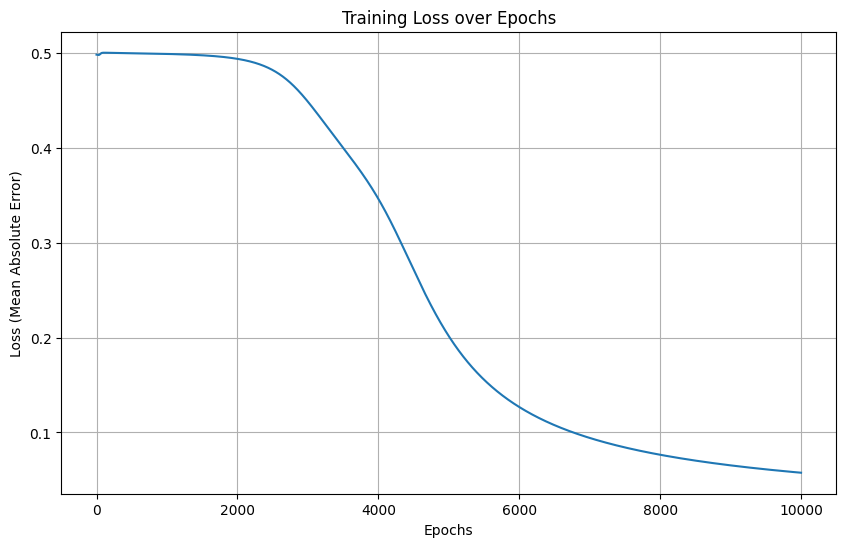

In [ ]:
# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Absolute Error)')
plt.grid(True)
plt.show()

### Part 3: PyTorch Implementation for XOR

Now, let's implement the same neural network for XOR using PyTorch, a popular deep learning framework.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

In [14]:
# Convert NumPy arrays to PyTorch tensors
X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

#### Define the Neural Network Model in PyTorch

We'll create a simple feedforward neural network using `nn.Module`.

In [15]:
class XOR_NN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(XOR_NN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size) # Input to hidden layer
        self.sigmoid = nn.Sigmoid()                     # Sigmoid activation
        self.fc2 = nn.Linear(hidden_size, output_size) # Hidden to output layer

    def forward(self, x):
        out = self.fc1(x)
        out = self.sigmoid(out)
        out = self.fc2(out)
        out = self.sigmoid(out) # Output layer also uses sigmoid for binary classification
        return out

# Instantiate the model
input_neurons_torch = 2
hidden_neurons_torch = 4
output_neurons_torch = 1

model = XOR_NN(input_neurons_torch, hidden_neurons_torch, output_neurons_torch)

print(model)

XOR_NN(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (sigmoid): Sigmoid()
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)


#### Loss Function and Optimizer

We'll use Mean Squared Error (MSE) as the loss function and Stochastic Gradient Descent (SGD) as the optimizer.

In [16]:
# Loss and optimizer
criterion = nn.MSELoss() # Mean Squared Error Loss
optimizer = optim.SGD(model.parameters(), lr=learning_rate) # Stochastic Gradient Descent

#### Training the PyTorch Model

Now, let's train the neural network using forward pass, backpropagation, and weight updates.

In [17]:
pytorch_losses = []

for epoch in range(epochs):
    # Forward pass
    outputs = model(X_torch)
    loss = criterion(outputs, y_torch)

    # Backward and optimize
    optimizer.zero_grad() # Clear gradients
    loss.backward()       # Compute gradients
    optimizer.step()      # Update weights

    pytorch_losses.append(loss.item())

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

print("\nPyTorch Training Complete.")

# Evaluate the model
with torch.no_grad(): # Disable gradient calculation for evaluation
    predicted_pytorch = model(X_torch).round()
    print("\nFinal Predicted Output (PyTorch, rounded):")
    print(predicted_pytorch.numpy())
    print("\nActual Output (y):")
    print(y_torch.numpy())

Epoch [1000/10000], Loss: 0.250070
Epoch [2000/10000], Loss: 0.249825
Epoch [3000/10000], Loss: 0.249516
Epoch [4000/10000], Loss: 0.248895
Epoch [5000/10000], Loss: 0.247237
Epoch [6000/10000], Loss: 0.242213
Epoch [7000/10000], Loss: 0.228711
Epoch [8000/10000], Loss: 0.203529
Epoch [9000/10000], Loss: 0.171586
Epoch [10000/10000], Loss: 0.129128

PyTorch Training Complete.

Final Predicted Output (PyTorch, rounded):
[[0.]
 [1.]
 [1.]
 [1.]]

Actual Output (y):
[[0.]
 [1.]
 [1.]
 [0.]]


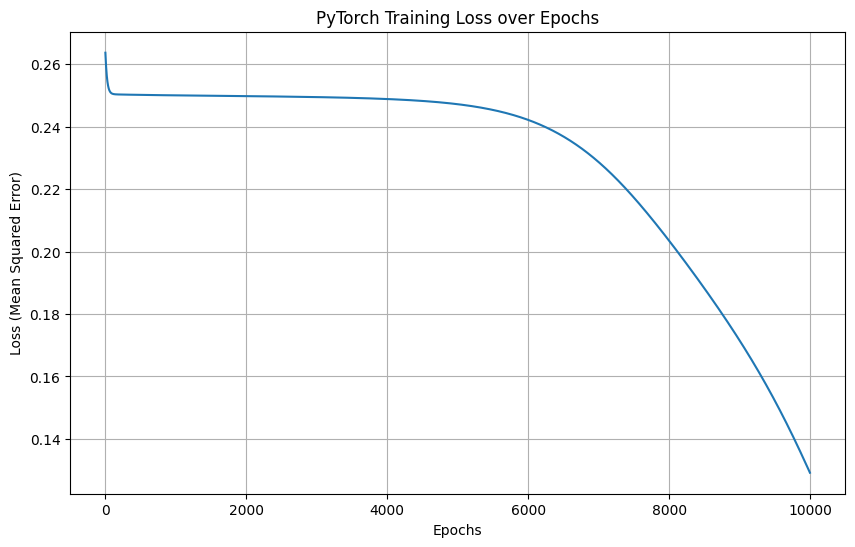

In [18]:
# Plot the PyTorch training loss
plt.figure(figsize=(10, 6))
plt.plot(pytorch_losses)
plt.title('PyTorch Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.grid(True)
plt.show()